## This program allows you to plot the perpendicular BAO distance and the parallel BAO distance.

In [1]:
#importing modules
import numpy as np
import matplotlib.pyplot as plt 
from fonction import trapezeVect

In [2]:
#Cosmological constant 
H0 = 67.14
Om = 0.3169
h = H0/100
wm = Om*h**2
wb = 0.02242
wp = 2.47e-5
wn = 1.7e-5
wr = 4.15e-5
wL = h**2-(wm+wr)
c = 3e5

#DESI best fit 
OmDESI = 0.2975
hrd = 101.54
OlDESI = 1-OmDESI

Zred = np.linspace(0.00001,2.5,50)

In [3]:
#Functions 
def DH(z) :
	return c/(100*np.sqrt(wm*(1+z)**3+wr*(1+z)**4+wL))	
def DHrddesi(z) : 
	return c/(100*hrd*np.sqrt(OmDESI*(1+z)**3+OlDESI))
def DM(z):
	return trapezeVect(DH,0,z,500)
def DMrddesi(z):
	return trapezeVect(DHrddesi,0,z,500)
	
def csHPlanck(z) : 
	R = (3 * wb) / (4 * wp * (1 + z))
	cs = c / np.sqrt(3 * (1 + R))
	Hz = 100 * np.sqrt(wm * (1 + z)**3 + wr * (1 + z)**4+wL)
	return cs/Hz 
def rdPlanck(z) :
	return trapezeVect(csHPlanck,1060,10e5,int(10e7))

In [4]:
#DESI data
redshift = np.array([0.510,0.706,0.934,1.321,1.484,2.330])
rdPlanck = np.ones(50)*rdPlanck(1060)

#experimental values
DMrd = np.array([13.588,17.351,21.576,27.601,30.512,38.988])
DHrd = np.array([21.863,19.455,17.641,14.176,12.817,8.632])

#uncertainty
IDMrd = np.array([0.167,0.177,0.152,0.318,0.760,0.531])
IDHrd = np.array([0.425,0.330,0.193,0.221,0.516,0.101])

In [5]:
#standardization
#DH
DHrddesi_vec = np.vectorize(DHrddesi)
DHrdbest = DHrddesi_vec(redshift)
DHrdbestPlanck = DHrddesi_vec(Zred)

#DM
DMrddesi_vec = np.vectorize(DMrddesi)
DMrdbest = DMrddesi_vec(redshift)
DMrdbestPlanck = (DMrddesi_vec(Zred))

IDM = IDMrd/DMrdbest
IDH = IDHrd/DHrdbest

In [6]:
#Lambda CDM model : 
DMPlanck_vec = np.vectorize(DM)
DMPlanck = DMPlanck_vec(Zred)
DMrdPlanck = DMPlanck/rdPlanck

DHPlanck_vec = np.vectorize(DH)
DHPlanck = DHPlanck_vec(Zred)
DHrdPlanck = DHPlanck/rdPlanck

In [7]:
#final functions
Perp = DMrd/DMrdbest
PerpPlanck = DMrdPlanck/DMrdbestPlanck

Para = DHrd/DHrdbest
ParaPlanck = DHrdPlanck/DHrdbestPlanck

DESI DR2 BAO measurements, with LRG (Luminous red galaxies), ELG (emission line galaxies) QSO (quasars) and Ly-$\alpha$.

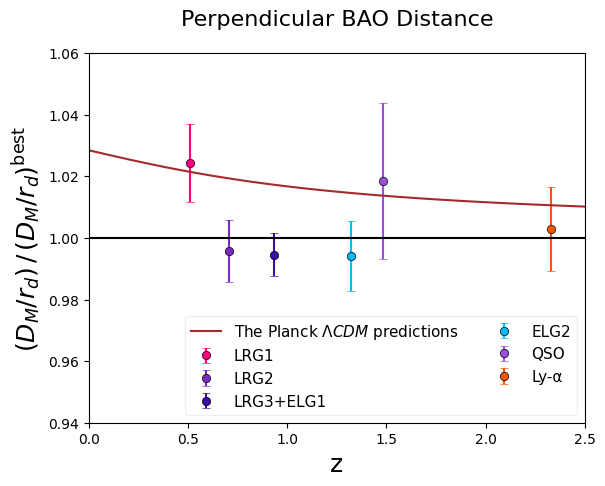

In [8]:
one = np.ones(50)
colors = ["#FF007F", "#7B2CBF", "#3A0CA3", "#00BBF9", "#9D4EDD", "#FF5400"]
tracers = [ "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", "Ly-α"]

for i, (z, y, ye, col, name) in enumerate(zip(redshift, Perp, IDM, colors, tracers)):
    plt.errorbar(z, y, yerr=ye, fmt='o', color=col,markeredgecolor='black', markeredgewidth=0.5,capsize=3, label=name)
plt.plot(Zred,one,'k')
plt.plot(Zred,PerpPlanck,'brown', label =r"The Planck $\Lambda CDM$ predictions" )
plt.title('Perpendicular BAO Distance',pad=20,fontsize=16)
plt.ylim(0.94,1.06)
plt.xlim(0,2.5)
plt.xlabel("z",fontsize=18)
plt.ylabel(r"$(D_M/r_d)\,/\,(D_M/r_d)^{\rm best}$",fontsize=18)
plt.legend(fontsize=11, ncol=2,loc='lower right',framealpha=0.3)
#plt.savefig("PerpendicularBAODistance.pdf",dpi = 300)
plt.show()

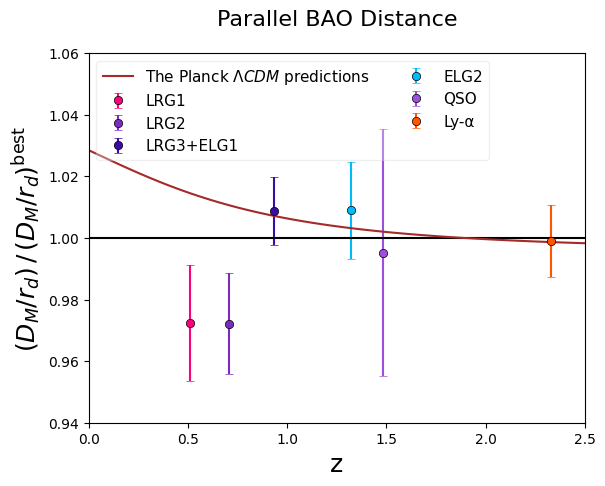

In [9]:
for i, (z, y, ye, col, name) in enumerate(zip(redshift, Para, IDH, colors, tracers)):
    plt.errorbar(z, y, yerr=ye, fmt='o', color=col,markeredgecolor='black', markeredgewidth=0.5,capsize=3, label=name)
plt.plot(Zred,one,'k')
plt.plot(Zred,ParaPlanck,'brown', label =r"The Planck $\Lambda CDM$ predictions" )
plt.title('Parallel BAO Distance',pad=20,fontsize=16)
plt.ylim(0.94,1.06)
plt.xlim(0,2.5)
plt.xlabel("z",fontsize = 18)
plt.ylabel(r"$(D_M/r_d)\,/\,(D_M/r_d)^{\rm best}$", fontsize = 18)
plt.legend(fontsize=11, ncol=2,loc='upper left',framealpha=0.3)
#plt.savefig("ParallelBAODistance.pdf",dpi = 300)
plt.show()